In [11]:
# ================================================
# Adventure Works - Retail EDA Project
# Author: Arpita
# Dataset: AdventureWorks Sales (Microsoft)
# Goal: End-to-End EDA + Power BI Dark Dashboard
# ================================================

In [12]:
# =============================================================
# STEP 0 — Setup Environment
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [13]:
# =============================================================
# STEP 1 — Load Dataset
# =============================================================

file_path = "C:/Users/Lenovo/OneDrive/Desktop/AdventureWorks/AdventureWorks Sales.xlsx"
sales = pd.read_excel(file_path, sheet_name="Sales_data")
customers = pd.read_excel(file_path, sheet_name="Customer_data")
products = pd.read_excel(file_path, sheet_name="Product_data")
territories = pd.read_excel(file_path, sheet_name="Sales Territory_data")
resellers = pd.read_excel(file_path, sheet_name="Reseller_data")
dates = pd.read_excel(file_path, sheet_name="Date_data")
orders = pd.read_excel(file_path,sheet_name="Sales Order_data")

print("All sheets loaded successfully")

All sheets loaded successfully


In [14]:
# =============================================================
# STEP 2 — Basic Exploration
# =============================================================

# 2a — Check size of each table
print("Sales_data:            ", sales.shape)
print("Customer_data:         ", customers.shape)
print("Product_data:          ", products.shape)
print("Sales Territory_data:  ", territories.shape)
print("Reseller_data:         ", resellers.shape)
print("Date_data:             ", dates.shape)
print("Sales Order_data:      ", orders.shape)

Sales_data:             (121253, 15)
Customer_data:          (18485, 7)
Product_data:           (397, 9)
Sales Territory_data:   (11, 4)
Reseller_data:          (702, 8)
Date_data:              (1461, 7)
Sales Order_data:       (121253, 4)


In [15]:
# 2b — Preview the main Sales table
sales.head() 

,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,SalesTerritoryKey,Order Quantity,Unit Price,Extended Amount,Unit Price Discount Pct,Product Standard Cost,Total Product Cost,Sales Amount
0,43659001,676,-1,349,20170702,20170712,20170709.0,5,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
1,43659002,676,-1,350,20170702,20170712,20170709.0,5,3,2024.994,6074.982,0,1898.0944,5694.2832,6074.982
2,43659003,676,-1,351,20170702,20170712,20170709.0,5,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
3,43659004,676,-1,344,20170702,20170712,20170709.0,5,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994
4,43659005,676,-1,345,20170702,20170712,20170709.0,5,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994


In [16]:
# 2c — Check missing values
sales.isnull().sum()

SalesOrderLineKey             0
ResellerKey                   0
CustomerKey                   0
ProductKey                    0
OrderDateKey                  0
DueDateKey                    0
ShipDateKey                2113
SalesTerritoryKey             0
Order Quantity                0
Unit Price                    0
Extended Amount               0
Unit Price Discount Pct       0
Product Standard Cost         0
Total Product Cost            0
Sales Amount                  0
dtype: int64

In [17]:
# 2d — Check data types
sales.dtypes

SalesOrderLineKey            int64
ResellerKey                  int64
CustomerKey                  int64
ProductKey                   int64
OrderDateKey                 int64
DueDateKey                   int64
ShipDateKey                float64
SalesTerritoryKey            int64
Order Quantity               int64
Unit Price                 float64
Extended Amount            float64
Unit Price Discount Pct      int64
Product Standard Cost      float64
Total Product Cost         float64
Sales Amount               float64
dtype: object

In [18]:
# 2e — Summary statistics
sales[['Order Quantity', 'Unit Price', 'Sales Amount', 'Total Product Cost', 'Unit Price Discount Pct']].describe()

,Order Quantity,Unit Price,Sales Amount,Total Product Cost,Unit Price Discount Pct
count,121253.000000,121253.000000,121253.000000,121253.000000,121253.0
mean,2.266138,465.180515,905.621091,802.107230,0.0
std,2.491806,752.041893,1693.746343,1660.416044,0.0
min,1.000000,1.328200,1.374000,0.856500,0.0
25%,1.000000,21.490000,24.990000,10.842300,0.0
50%,1.000000,49.990000,134.982000,98.983600,0.0
75%,3.000000,602.346000,1120.490000,999.259500,0.0
max,44.000000,3578.270000,27893.619000,38530.385400,0.0


In [19]:
# =============================================================
# STEP 3 — Data Cleaning
# =============================================================

# 3a — Convert OrderDateKey to real date format
sales['OrderDate'] = pd.to_datetime(sales['OrderDateKey'], format='%Y%m%d')

#Extract useful time columns
sales['Year'] = sales['OrderDate'].dt.year
sales['Month'] = sales['OrderDate'].dt.month
sales['MonthName'] = sales['OrderDate'].dt.strftime('%b')
sales['Quarter'] = sales['OrderDate'].dt.quarter

print("Date columns created")
print(sales[['OrderDateKey', 'OrderDate', 'Year', 'Month', 'MonthName', 'Quarter']].head())

Date columns created
   OrderDateKey  OrderDate  Year  Month MonthName  Quarter
0      20170702 2017-07-02  2017      7       Jul        3
1      20170702 2017-07-02  2017      7       Jul        3
2      20170702 2017-07-02  2017      7       Jul        3
3      20170702 2017-07-02  2017      7       Jul        3
4      20170702 2017-07-02  2017      7       Jul        3


In [20]:
# 3b — Handle missing ShipDate
sales['ShipDateKey'] = sales['ShipDateKey'].fillna(0).astype(int)

print("Missing ShipDate handled")

Missing ShipDate handled


In [21]:
# 3c — Calculate actual Discount Amount
sales['Discount Amount'] = sales['Extended Amount'] - sales['Sales Amount']

print("Discount Amount column created")
print(f"\nSample discounts:\n{sales['Discount Amount'].describe()}")

Discount Amount column created

Sample discounts:
count    121253.000000
mean          4.350473
std          62.309687
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4005.237600
Name: Discount Amount, dtype: float64


In [22]:
# 3d — Create Profit column
sales['Profit'] = sales['Sales Amount'] - sales['Total Product Cost']
sales['Profit Margin %'] = (sales['Profit']/sales['Sales Amount']*100).round(2)

print("Profit columns created")
print(f"\n Average Profit per order: ${sales['Profit'].mean():.2f}")
print(f"Average Profit Margin: {sales['Profit Margin %'].mean():.2f}")

Profit columns created

 Average Profit per order: $103.51
Average Profit Margin: 30.30


In [23]:
# 3e — Merge all tables into one master dataframe
master = sales.copy()

# Merge with territories
master = master.merge(territories, on='SalesTerritoryKey', how='left')

# Merge with products
master = master.merge(products, on='ProductKey', how='left')

# Merge with customers
master = master.merge(customers, on='CustomerKey', how='left')

# Merge with orders (to get the channel info)
master = master.merge(orders, on='SalesOrderLineKey', how='left')

print("Master Dataframe created!")
print(f"Shape: {master.shape}")
print(f"\nColumns: {list(master.columns)}")

Master Dataframe created!
Shape: (121253, 43)

Columns: ['SalesOrderLineKey', 'ResellerKey', 'CustomerKey', 'ProductKey', 'OrderDateKey', 'DueDateKey', 'ShipDateKey', 'SalesTerritoryKey', 'Order Quantity', 'Unit Price', 'Extended Amount', 'Unit Price Discount Pct', 'Product Standard Cost', 'Total Product Cost', 'Sales Amount', 'OrderDate', 'Year', 'Month', 'MonthName', 'Quarter', 'Discount Amount', 'Profit', 'Profit Margin %', 'Region', 'Country', 'Group', 'SKU', 'Product', 'Standard Cost', 'Color', 'List Price', 'Model', 'Subcategory', 'Category', 'Customer ID', 'Customer', 'City', 'State-Province', 'Country-Region', 'Postal Code', 'Channel', 'Sales Order', 'Sales Order Line']


In [24]:
# 3f — Sanity check on master dataframe

print("=== MASTER DATAFRAME SUMMARY ===\n")
print(f"Total Orders:  {master.shape[0]:,}")
print(f"Total Columns: {master.shape[1]}")
print(f"Date Range:  {master['OrderDate'].min()} to {master['OrderDate'].max()}")
print(f"Total Revenue:  ${master['Sales Amount'].sum():,.2f}")
print(f"Total Profit: ${master['Profit'].sum():,.2f}")
print(f"Countries: {master['Country'].nunique()} - {list(master['Country'].unique())}")
print(f"Product Categories:  {master['Category'].nunique()} - {list(master['Category'].unique())}")
print(f"Sales Channels:  {list(master['Channel'].unique())}")

=== MASTER DATAFRAME SUMMARY ===

Total Orders:  121,253
Total Columns: 43
Date Range:  2017-07-01 00:00:00 to 2020-06-15 00:00:00
Total Revenue:  $109,809,274.20
Total Profit: $12,551,366.25
Countries: 6 - ['United States', 'Canada', 'United Kingdom', 'France', 'Australia', 'Germany']
Product Categories:  4 - ['Bikes', 'Clothing', 'Accessories', 'Components']
Sales Channels:  ['Reseller', 'Internet']


In [25]:
# =============================================================
# STEP 4 — Create Key Metrics
# =============================================================

# 4a — Label channel type clearly
master['CustomerType'] = master['Channel'].apply(lambda x: 'B2B' if x=='Reseller' else 'B2C')

#Check the split
print(master['CustomerType'].value_counts())
print()
print(master['CustomerType'].value_counts(normalize=True).mul(100).round(2))

CustomerType
B2B    60855
B2C    60398
Name: count, dtype: int64

CustomerType
B2B    50.19
B2C    49.81
Name: proportion, dtype: float64


In [26]:
# 4b — Revenue per order & Price Bands
master['Revenue per Order'] = (master['Sales Amount']/master['Order Quantity']).round(2)

master['Price Band'] = pd.cut(master['Unit Price'], bins=[0, 50, 200, 500, 4000], labels=['Budget', 'Mid-Range', 'Premium', 'Luxury'])

print("Key Metrics created")
print("\nPrice Band Distribution:")
print(master['Price Band'].value_counts())

Key Metrics created

Price Band Distribution:
Price Band
Budget       60827
Luxury       33238
Premium      14888
Mid-Range    12300
Name: count, dtype: int64


In [27]:
# =============================================================
# STEP 5 — Revenue by Category
# =============================================================

category_revenue = master.groupby('Category')['Sales Amount'].sum().sort_values(ascending=False).reset_index()
category_revenue.columns = ['Category', 'Total Revenue']
category_revenue['Revenue(M)'] = (category_revenue['Total Revenue']/1_000_000).round(2)

print(category_revenue)

      Category  Total Revenue  Revenue(M)
0        Bikes   9.462053e+07       94.62
1   Components   1.179908e+07       11.80
2     Clothing   2.117613e+06        2.12
3  Accessories   1.272058e+06        1.27


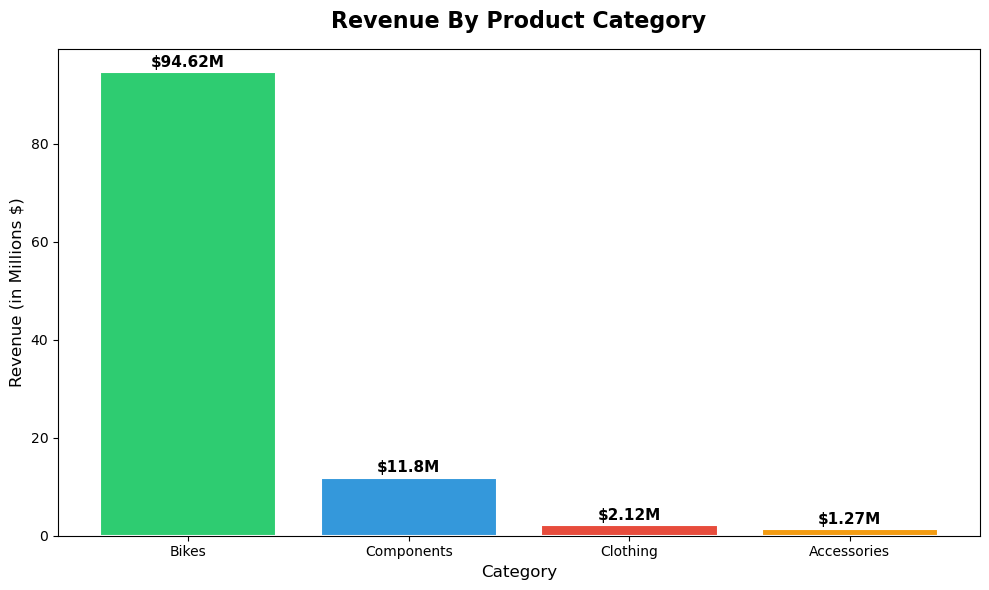

Chart saved


In [28]:
# STEP 5 — Revenue by Category Chart

plt.figure(figsize=(10,6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

bars = plt.bar(category_revenue['Category'], category_revenue['Revenue(M)'], color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
for bar, val in zip(bars, category_revenue['Revenue(M)']):
         plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
         f'${val}M', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Revenue By Product Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Revenue (in Millions $)', fontsize=12)
plt.tight_layout()
plt.savefig('step5_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved")           

In [29]:
# =============================================================
# STEP 6 — Top 10 Products by Revenue
# =============================================================

top_products = master.groupby('Product')['Sales Amount'].sum()\
                     .sort_values(ascending=False)\
                     .head(10)\
                     .reset_index()
top_products.columns = ['Product', 'Total Revenue']
top_products['Revenue (M)'] = (top_products['Total Revenue']/1_000_000).round(2)

print(top_products)

                   Product  Total Revenue  Revenue (M)
0   Mountain-200 Black, 38   4.400593e+06         4.40
1   Mountain-200 Black, 42   4.009495e+06         4.01
2  Mountain-200 Silver, 38   3.693678e+06         3.69
3  Mountain-200 Silver, 42   3.438479e+06         3.44
4  Mountain-200 Silver, 46   3.434257e+06         3.43
5   Mountain-200 Black, 46   3.309673e+06         3.31
6       Road-250 Black, 44   2.516857e+06         2.52
7       Road-250 Black, 48   2.347656e+06         2.35
8       Road-250 Black, 52   2.012448e+06         2.01
9         Road-150 Red, 56   1.847819e+06         1.85


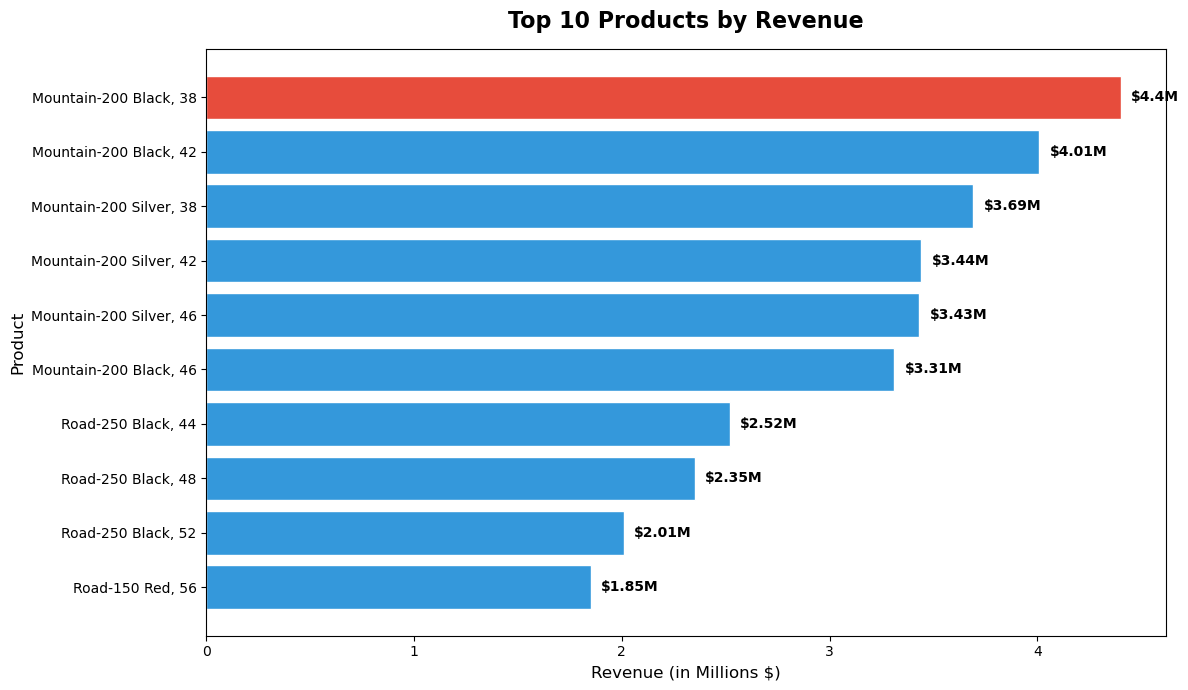

Chart saved


In [30]:
# STEP 6 — Top Products Chart

plt.figure(figsize=(12,7))

colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(top_products))]

bars = plt.barh(top_products['Product'][::-1],
                top_products['Revenue (M)'][::-1],
                color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_products['Revenue (M)'][::-1]):
    plt.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f'${val}M', va='center', fontweight='bold', fontsize=10)

plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Revenue (in Millions $)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig('step6_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved")

In [31]:
# =============================================================
# STEP 7 — Regional Performance
# =============================================================

country_revenue = master.groupby('Country').agg(
    Total_Revenue = ('Sales Amount', 'sum'),
    Total_Orders = ('SalesOrderLineKey', 'count'),
    Total_Profit = ('Profit', 'sum')).reset_index()
country_revenue['Revenue (M)'] = (country_revenue['Total_Revenue']/1_000_000).round(2)
country_revenue['Profit (M)'] = (country_revenue['Total_Profit']/1_000_000).round(2)
country_revenue['Margin %'] = (country_revenue['Total_Profit']/country_revenue['Total_Revenue']*100).round(2)
country_revenue = country_revenue.sort_values('Revenue (M)', ascending=False)

print(country_revenue[['Country', 'Revenue (M)', 'Total_Orders', 'Profit (M)', 'Margin %']])

          Country  Revenue (M)  Total_Orders  Profit (M)  Margin %
5   United States        63.00         60153        4.44      7.05
1          Canada        16.36         19064        1.01      6.16
0       Australia        10.66         15058        3.58     33.57
4  United Kingdom         7.67         10426        1.40     18.21
2          France         7.25          9088        1.05     14.47
3         Germany         4.88          7464        1.08     22.06


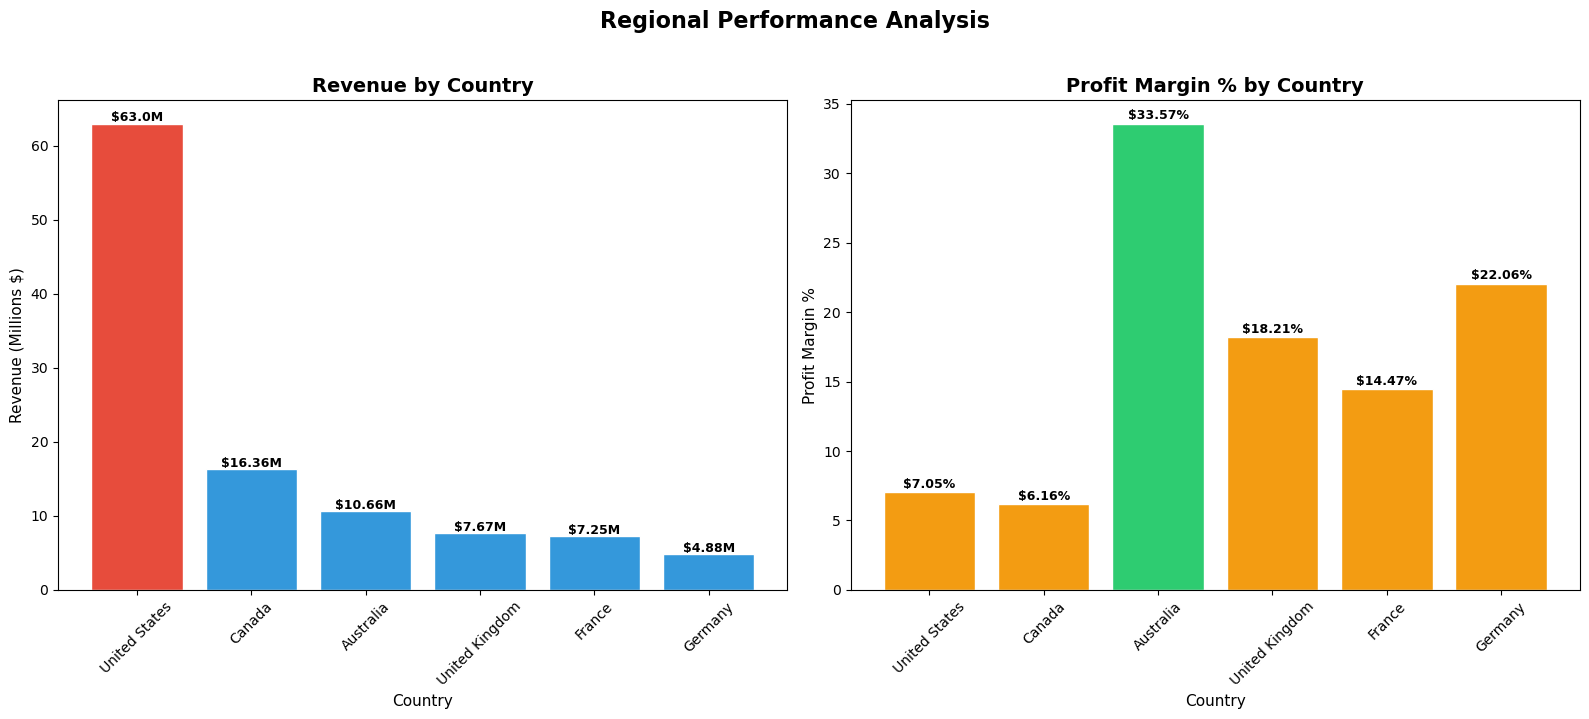

Chart saved


In [32]:
# STEP 7 — Regional Performance Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,7))

# Chart 1 — Revenue by Country
colors_rev = ['#e74c3c' if c == 'United States' else '#3498db' 
              for c in country_revenue['Country']]
bars1 = ax1.bar(country_revenue['Country'],
                country_revenue['Revenue (M)'],
                color=colors_rev, edgecolor='white')
for bar, val in zip(bars1, country_revenue['Revenue (M)']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'${val}M', ha='center', fontweight='bold', fontsize=9)

ax1.set_title('Revenue by Country', fontsize=14, fontweight='bold')
ax1.set_xlabel('Country', fontsize=11)
ax1.set_ylabel('Revenue (Millions $)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)


# Chart 2 — Profit Margin by Country
colors_margin = ['#2ecc71' if c == 'Australia' else '#f39c12' 
                 for c in country_revenue['Country']]
bars2 = ax2.bar(country_revenue['Country'],
                country_revenue['Margin %'],
                color=colors_margin, edgecolor='white')
for bar, val in zip(bars2, country_revenue['Margin %']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'${val}%', ha='center', fontweight='bold', fontsize=9)

ax2.set_title('Profit Margin % by Country', fontsize=14, fontweight='bold')
ax2.set_xlabel('Country', fontsize=11)
ax2.set_ylabel('Profit Margin %', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Regional Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step7_regional_performane.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [33]:
# =============================================================
# STEP 8 — Discount Impact Analysis
# =============================================================

# Label discounted and non-discounted orders
master['Has_Discount']=master['Discount Amount'].apply(
    lambda x: 'Discounted' if x>0 else 'No Discount')

# Group and Analyse
discounted = master[master['Has_Discount'] == 'Discounted']
no_discount = master[master['Has_Discount'] == 'No Discount']

print("========== DISCOUNT IMPACT ANALYSIS ==========\n")
print(f"Total Orders:   {len(master):,}")
print(f"Discounted Orders: {len(discounted):,} ({len(discounted)/len(master)*100:.1f}%)")
print(f"Non_Discounted Orders: {len(no_discount):,} ({len(no_discount)/len(master)*100:.1f}%)")

print("\n---------- Discounted Orders ----------")
print(f"  Avg Sales Amount:   ${discounted['Sales Amount'].mean():,.2f}")
print(f"  Avg Profit:         ${discounted['Profit'].mean():,.2f}")
print(f"  Avg Margin:         {discounted['Profit Margin %'].mean():,.2f}%")
print(f"  Total Revenue:      ${discounted['Sales Amount'].sum()/1_000_000:,.2f}M")

print("\n---------- Non-Discounted Orders ----------")
print(f"  Avg Sales Amount:   ${no_discount['Sales Amount'].mean():,.2f}")
print(f"  Avg Profit:         ${no_discount['Profit'].mean():,.2f}")
print(f"  Avg Margin:         {no_discount['Profit Margin %'].mean():,.2f}%")
print(f"  Total Revenue:      ${no_discount['Sales Amount'].sum()/1_000_000:,.2f}M")

========== DISCOUNT IMPACT ANALYSIS ==========

Total Orders:   121,253
Discounted Orders: 3,282 (2.7%)
Non_Discounted Orders: 117,971 (97.3%)

---------- Discounted Orders ----------
  Avg Sales Amount:   $1,652.25
  Avg Profit:         $-556.22
  Avg Margin:         -42.66%
  Total Revenue:      $5.42M

---------- Non-Discounted Orders ----------
  Avg Sales Amount:   $884.85
  Avg Profit:         $121.87
  Avg Margin:         32.33%
  Total Revenue:      $104.39M


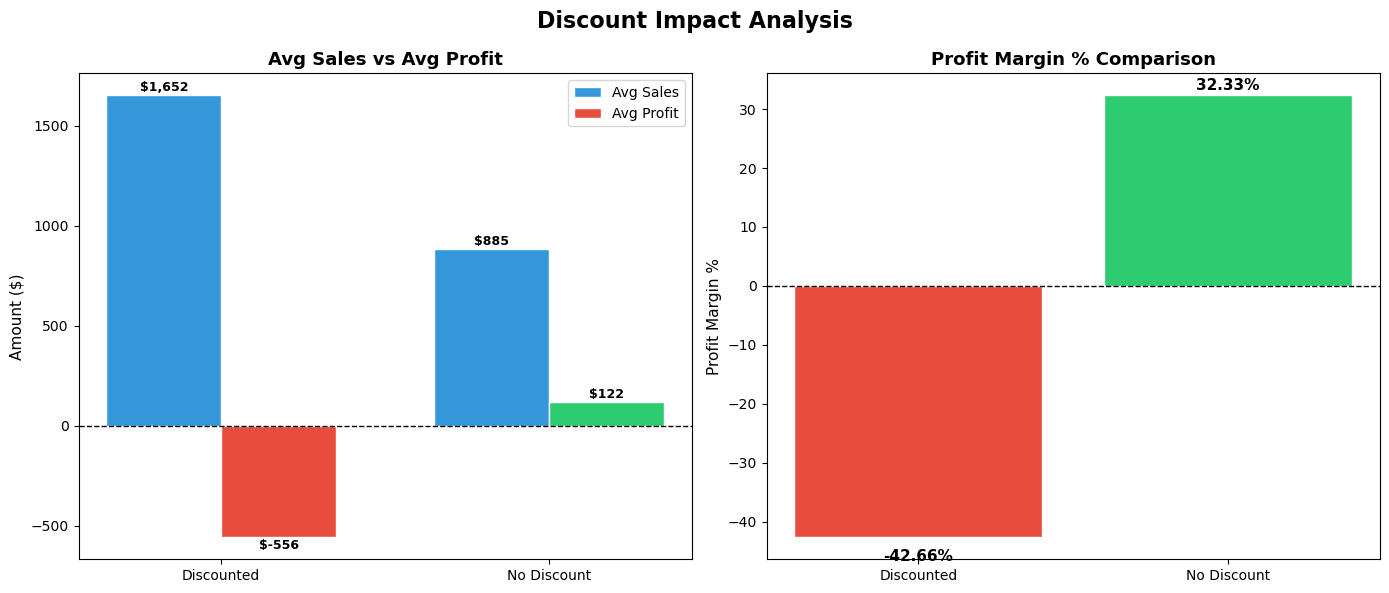

Chart saved


In [34]:
# STEP 8 — Discount Impact Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

categories = ['Discounted', 'No Discount']
avg_sales = [1652.25, 884.85]
avg_profit = [-556.22, 121.87]
avg_margin = [-42.66, 32.33]

# Chart 1 — Avg Sales vs Avg Profit
x = range(len(categories))
width = 0.35
bars1 = ax1.bar([i - width/2 for i in x], avg_sales, width,
                label='Avg Sales', color=['#3498db', '#3498db'], 
                edgecolor='white')
bars2 = ax1.bar([i + width/2 for i in x], avg_profit, width,
                label='Avg Profit', 
                color=['#e74c3c', '#2ecc71'], edgecolor='white')

ax1.set_title('Avg Sales vs Avg Profit', fontsize=13, fontweight='bold')
ax1.set_xticks(list(x))
ax1.set_xticklabels(categories)
ax1.set_ylabel('Amount ($)', fontsize=11)
ax1.legend()
ax1.axhline(y=0, color='black', linewidth=1, linestyle='--')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             f'${bar.get_height():,.0f}',
             ha='center', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, avg_profit):
    offset = 20 if val > 0 else -60
    ax1.text(bar.get_x() + bar.get_width()/2,
             val + offset,
             f'${val:,.0f}',
             ha='center', fontsize=9, fontweight='bold')

# Chart 2 — Profit Margin %
colors_margin = ['#e74c3c', '#2ecc71']
bars3 = ax2.bar(categories, avg_margin, color=colors_margin, edgecolor='white')
for bar, val in zip(bars3, avg_margin):
    offset = 1 if val > 0 else -4
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + offset,
             f'{val}%', ha='center', fontweight='bold', fontsize=11)
ax2.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax2.set_title('Profit Margin % Comparison', fontsize=13, fontweight='bold')
ax2.set_ylabel('Profit Margin %', fontsize=11)

plt.suptitle('Discount Impact Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('step8_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [35]:
# =============================================================
# STEP 9 — Monthly Sales Trend
# =============================================================

monthly_sales = master.groupby(['Year', 'Month', 'MonthName']).agg(
    Revenue=('Sales Amount', 'sum'),
    Orders=('SalesOrderLineKey', 'count'),
    Profit=('Profit', 'sum')).reset_index()

monthly_sales = monthly_sales.sort_values(['Year', 'Month'])
monthly_sales['Revenue (K)'] = (monthly_sales['Revenue']/1000).round(2)
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str)+'_'+monthly_sales['Month'].astype(str).str.zfill(2)

print(monthly_sales[['YearMonth', 'Revenue (K)', 'Orders', 'Profit']].to_string())

   YearMonth  Revenue (K)  Orders       Profit
0    2017_07      1423.36     641  393211.3299
1    2017_08      2057.90     944  276100.3995
2    2017_09      2523.95    1253  291127.1389
3    2017_10       561.68     174  226029.5485
4    2017_11      4764.92    2139  454064.5283
5    2017_12       596.75     188  240320.9096
6    2018_01      1327.67     570  267763.8691
7    2018_02      3936.46    1696  362623.1170
8    2018_03       700.87     219  282033.7706
9    2018_04      1519.28     696  285538.8334
10   2018_05      2960.38    1334  366425.3535
11   2018_06      1487.67    1064 -409305.2306
12   2018_07      2939.69    2004  277134.3707
13   2018_08      3964.80    3170  279976.3481
14   2018_09      3287.61    2406  316094.7181
15   2018_10      2157.29    1610  222186.4617
16   2018_11      3611.09    2664  367754.6967
17   2018_12      2624.08    1976  295432.9284
18   2019_01      1847.69    1281  272760.1732
19   2019_02      2829.36    1910  263242.6210
20   2019_03 

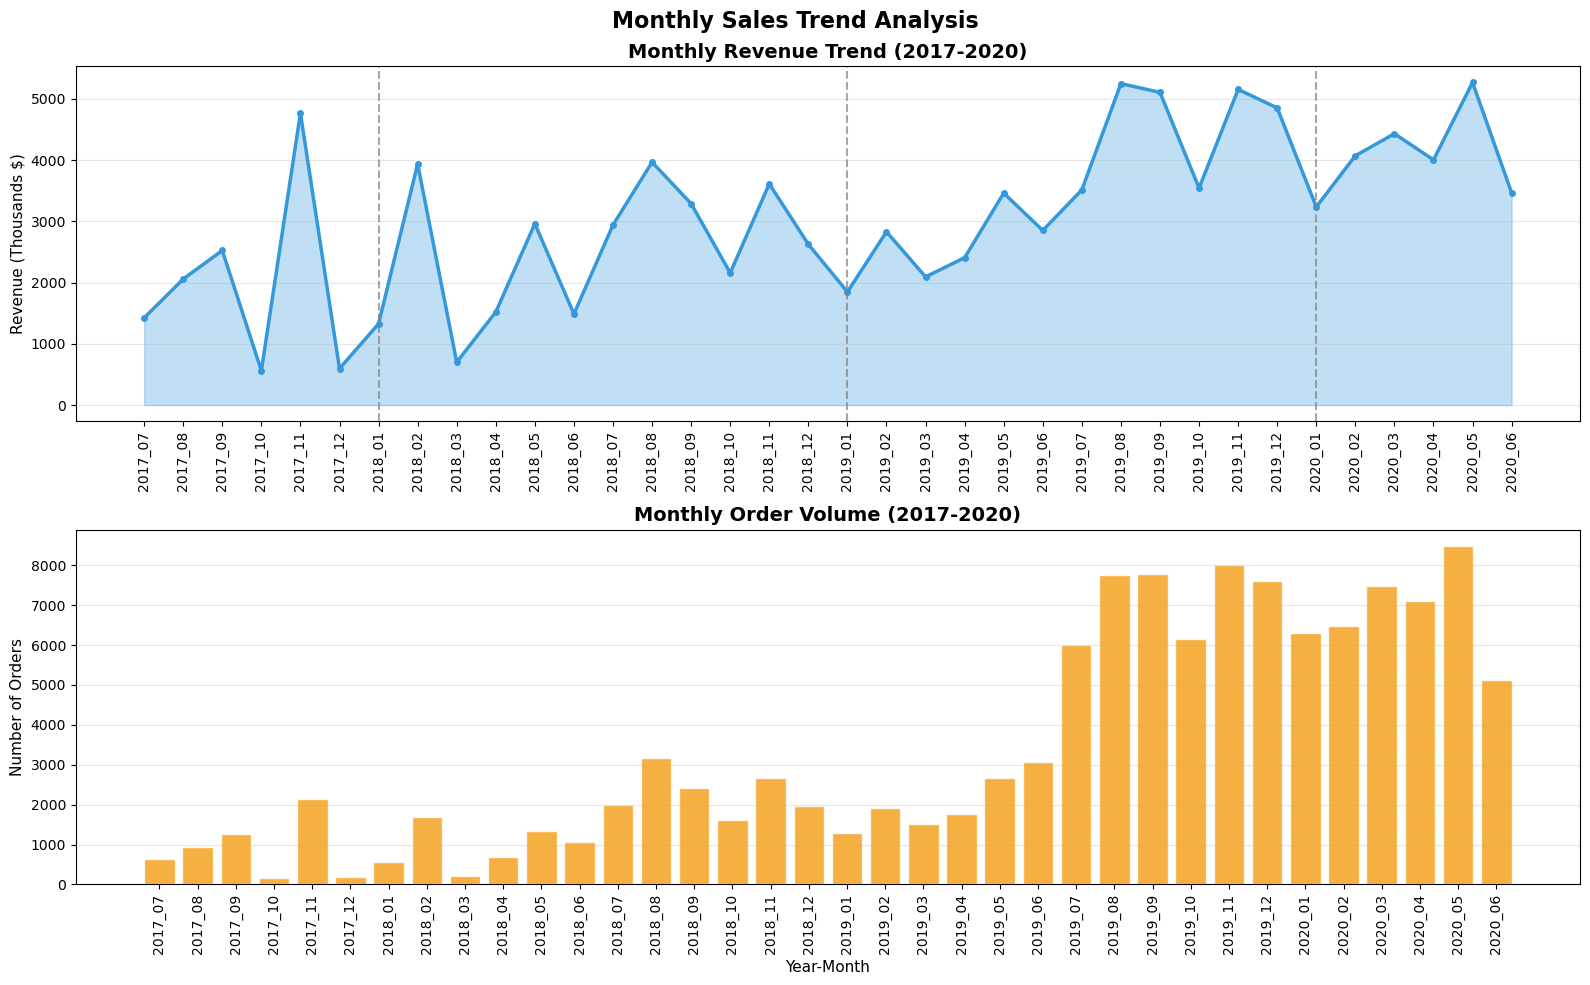

Chart saved


In [36]:
# STEP 9 — Monthly Sales Trend Chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Chart 1 — Revenue trend line
ax1.plot(monthly_sales['YearMonth'], 
         monthly_sales['Revenue (K)'],
         color='#3498db', linewidth=2.5, marker='o', markersize=4)
ax1.fill_between(monthly_sales['YearMonth'],
                 monthly_sales['Revenue (K)'],
                 alpha=0.3, color='#3498db')

# Add year separator lines
for year in ['2018_01', '2019_01', '2020_01']:
    if year in monthly_sales['YearMonth'].values:
        idx = monthly_sales[monthly_sales['YearMonth'] == year].index[0]
        ax1.axvline(x=monthly_sales['YearMonth'].iloc[idx - monthly_sales.index[0]], 
                    color='gray', linestyle='--', alpha=0.7)

ax1.set_title('Monthly Revenue Trend (2017-2020)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Revenue (Thousands $)', fontsize=11)
ax1.tick_params(axis='x', rotation=90)
ax1.grid(axis='y', alpha=0.3)

# Chart 2 — Orders trend
colors_bar = ['#e74c3c' if p < 0 else '#2ecc71' 
              for p in monthly_sales['Profit']]
ax2.bar(monthly_sales['YearMonth'],
        monthly_sales['Orders'],
        color='#f39c12', edgecolor='white', alpha=0.8)
ax2.set_title('Monthly Order Volume (2017-2020)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.set_xlabel('Year-Month', fontsize=11)
ax2.tick_params(axis='x', rotation=90)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Monthly Sales Trend Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('step9_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [41]:
# =============================================================
# STEP 10 — Profitability Analysis
# =============================================================

profit_category = master.groupby('Category').agg(
    Revenue = ('Sales Amount', 'sum'),
    Cost = ('Total Product Cost', 'sum'),
    Profit = ('Profit', 'sum')).reset_index()

profit_category['Revenue (M)'] = (profit_category['Revenue']/1_000_000).round(2)
profit_category['Profit (M)'] = (profit_category['Profit']/1_000_000).round(2)
profit_category['Margin %'] = (profit_category['Profit']/profit_category['Revenue']*100).round(2)
profit_category = profit_category.sort_values('Margin %', ascending=False)

print("===== PROFITIBALITY BY CATEGORY =====\n")
for _, row in profit_category.iterrows():
    print(f"{row['Category']:<15}  Revenue: ${row['Revenue (M)']}M  Profit: ${row['Profit (M)']}M  Margin: {row['Margin %']}%")

===== PROFITIBALITY BY CATEGORY =====

Accessories      Revenue: $1.27M  Profit: $0.63M  Margin: 49.88%
Clothing         Revenue: $2.12M  Profit: $0.37M  Margin: 17.42%
Bikes            Revenue: $94.62M  Profit: $10.52M  Margin: 11.11%
Components       Revenue: $11.8M  Profit: $1.03M  Margin: 8.75%


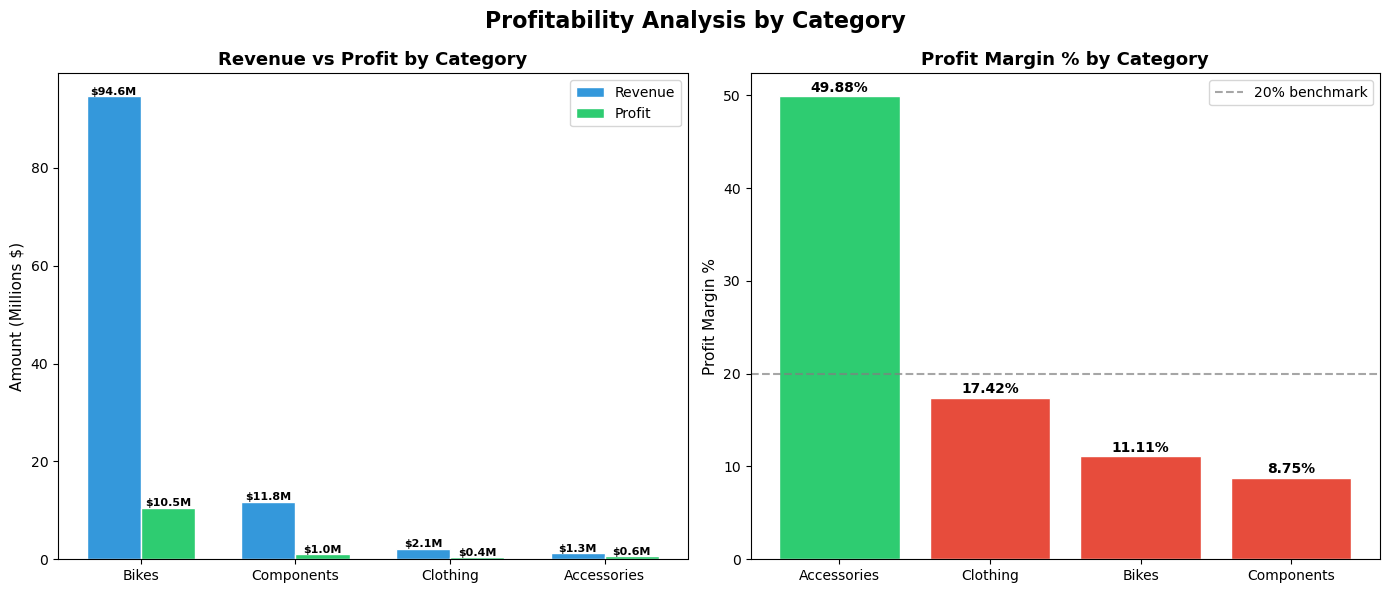

Chart saved


In [42]:
# STEP 10 — Profitability Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

profit_category_sorted_rev = profit_category.sort_values('Revenue (M)', ascending=False)

# Chart 1 — Revenue vs Profit side by side
x = range(len(profit_category_sorted_rev))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x],
                profit_category_sorted_rev['Revenue (M)'],
                width, label='Revenue', color='#3498db', edgecolor='white')
bars2 = ax1.bar([i + width/2 for i in x],
                profit_category_sorted_rev['Profit (M)'],
                width, label='Profit', color='#2ecc71', edgecolor='white')

ax1.set_xticks(list(x))
ax1.set_xticklabels(profit_category_sorted_rev['Category'])
ax1.set_title('Revenue vs Profit by Category', fontsize=13, fontweight='bold')
ax1.set_ylabel('Amount (Millions $)', fontsize=11)
ax1.legend()

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'${bar.get_height():.1f}M',
             ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'${bar.get_height():.1f}M',
             ha='center', fontsize=8, fontweight='bold')

# Chart 2 — Margin % 
colors_margin = ['#e74c3c' if m < 20 else '#2ecc71' 
                 for m in profit_category['Margin %']]
bars3 = ax2.bar(profit_category['Category'],
                profit_category['Margin %'],
                color=colors_margin, edgecolor='white')
for bar, val in zip(bars3, profit_category['Margin %']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontweight='bold', fontsize=10)

ax2.set_title('Profit Margin % by Category', fontsize=13, fontweight='bold')
ax2.set_ylabel('Profit Margin %', fontsize=11)
ax2.axhline(y=20, color='gray', linestyle='--', alpha=0.7, label='20% benchmark')
ax2.legend()

plt.suptitle('Profitability Analysis by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('step10_profitability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [45]:
# =============================================================
# STEP 11 — Top Customers (Pareto Analysis)
# =============================================================

customer_revenue = master[master['CustomerType'] == 'B2C'].groupby('Customer').agg(
    Total_Revenue = ('Sales Amount', 'sum'),
    Total_Orders = ('SalesOrderLineKey', 'count'),
    Total_Profit = ('Profit', 'sum')).reset_index()

customer_revenue = customer_revenue.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)
customer_revenue['Revenue (K)'] = (customer_revenue['Total_Revenue']/1000).round(2)
customer_revenue['Cumulative %'] = (customer_revenue['Total_Revenue'].cumsum()/customer_revenue['Total_Revenue'].sum()*100).round(2)

print(f"Total B2C Customers: {len(customer_revenue):,}")
print(f"\nTop 10 Customers:")
print(customer_revenue[['Customer', 'Revenue (K)', 'Total_Orders', 'Cumulative %']].head(10).to_string())

Total B2C Customers: 18,400

Top 10 Customers:
            Customer  Revenue (K)  Total_Orders  Cumulative %
0      Jordan Turner        16.00            20          0.05
1          Willie Xu        13.49             9          0.10
2       Nichole Nara        13.30            13          0.15
3  Kaitlyn Henderson        13.29            14          0.19
4        Margaret He        13.27            14          0.24
5  Randall Dominguez        13.27            11          0.28
6   Adriana Gonzalez        13.24            10          0.33
7            Rosa Hu        13.22            15          0.37
8        Brandi Gill        13.20            12          0.42
9           Brad She        13.17            11          0.46


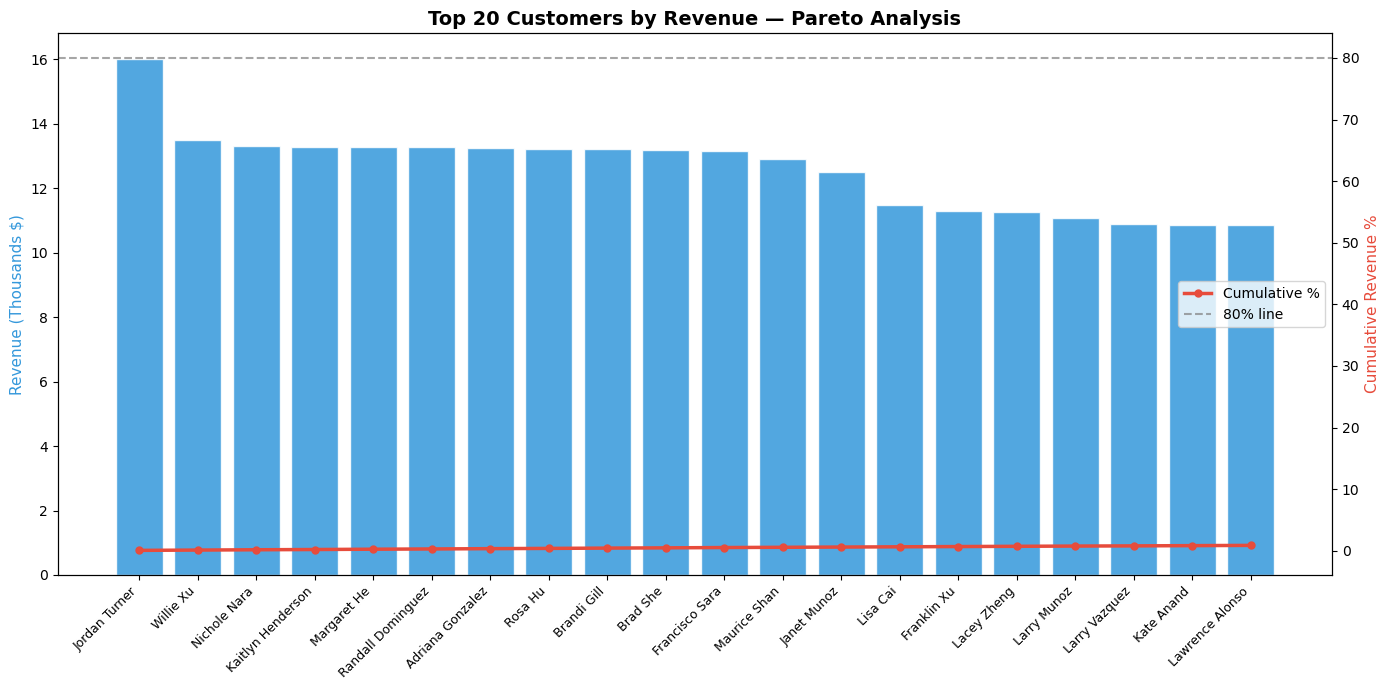

Chart saved


In [47]:
# STEP 11 — Top Customers Pareto Chart
top20 = customer_revenue.head(20)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart — revenue
bars = ax1.bar(range(len(top20)), 
               top20['Revenue (K)'],
               color='#3498db', edgecolor='white', alpha=0.85)
ax1.set_xticks(range(len(top20)))
ax1.set_xticklabels(top20['Customer'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Revenue (Thousands $)', fontsize=11, color='#3498db')
ax1.set_title('Top 20 Customers by Revenue — Pareto Analysis', 
              fontsize=14, fontweight='bold')

# Pareto line — cumulative %
ax2 = ax1.twinx()
ax2.plot(range(len(top20)), 
         top20['Cumulative %'],
         color='#e74c3c', linewidth=2.5, 
         marker='o', markersize=5, label='Cumulative %')
ax2.set_ylabel('Cumulative Revenue %', fontsize=11, color='#e74c3c')
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% line')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('step11_pareto_customers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [48]:
# =============================================================
# STEP 12 — Repeat Customers
# =============================================================

# Count orders per customer (B2C only)
customer_orders = master[master['CustomerType'] == 'B2C'].groupby('Customer').agg(
    Order_Count=('SalesOrderLineKey', 'count'),
    Total_Revenue=('Sales Amount', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# Label them
customer_orders['Customer_Type'] = customer_orders['Order_Count'].apply(
    lambda x: 'One-Time' if x == 1 
    else ('Repeat (2-5)' if x <= 5 
    else 'Loyal (6+)')
)

summary = customer_orders.groupby('Customer_Type').agg(
    Customer_Count=('Customer', 'count'),
    Avg_Revenue=('Total_Revenue', 'mean'),
    Total_Revenue=('Total_Revenue', 'sum')
).reset_index()

summary['Revenue (M)'] = (summary['Total_Revenue'] / 1_000_000).round(2)
summary['Avg_Revenue'] = summary['Avg_Revenue'].round(2)

print("===== REPEAT CUSTOMER ANALYSIS =====\n")
print(summary[['Customer_Type', 'Customer_Count', 'Avg_Revenue', 'Revenue (M)']].to_string())

===== REPEAT CUSTOMER ANALYSIS =====

  Customer_Type  Customer_Count  Avg_Revenue  Revenue (M)
0    Loyal (6+)            1683      3786.23         6.37
1      One-Time            2471       775.46         1.92
2  Repeat (2-5)           14246      1479.03        21.07


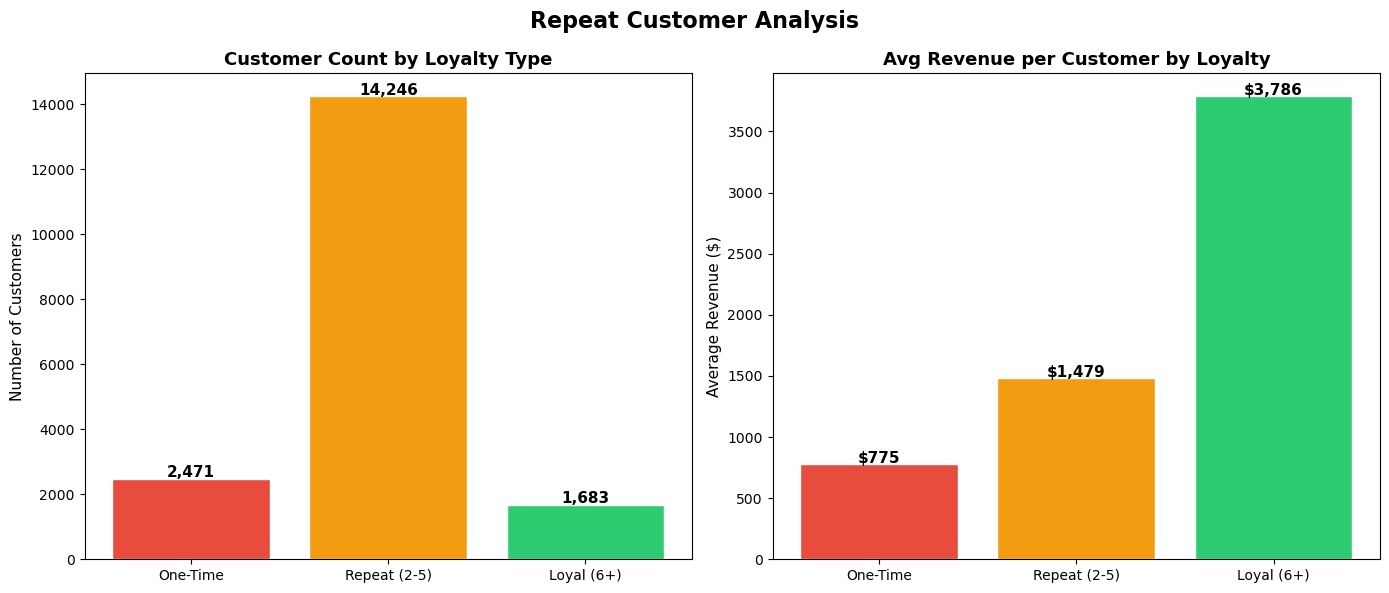

Chart saved


In [50]:
# STEP 12 — Repeat Customer Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

order = ['One-Time', 'Repeat (2-5)', 'Loyal (6+)']
summary_sorted = summary.set_index('Customer_Type').reindex(order).reset_index()

colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Chart 1 — Customer Count
bars1 = ax1.bar(summary_sorted['Customer_Type'],
                summary_sorted['Customer_Count'],
                color=colors, edgecolor='white')
for bar, val in zip(bars1, summary_sorted['Customer_Count']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax1.set_title('Customer Count by Loyalty Type', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Customers', fontsize=11)

# Chart 2 — Avg Revenue per Customer
bars2 = ax2.bar(summary_sorted['Customer_Type'],
                summary_sorted['Avg_Revenue'],
                color=colors, edgecolor='white')
for bar, val in zip(bars2, summary_sorted['Avg_Revenue']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Avg Revenue per Customer by Loyalty', fontsize=13, fontweight='bold')
ax2.set_ylabel('Average Revenue ($)', fontsize=11)

plt.suptitle('Repeat Customer Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('step12_repeat_customers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

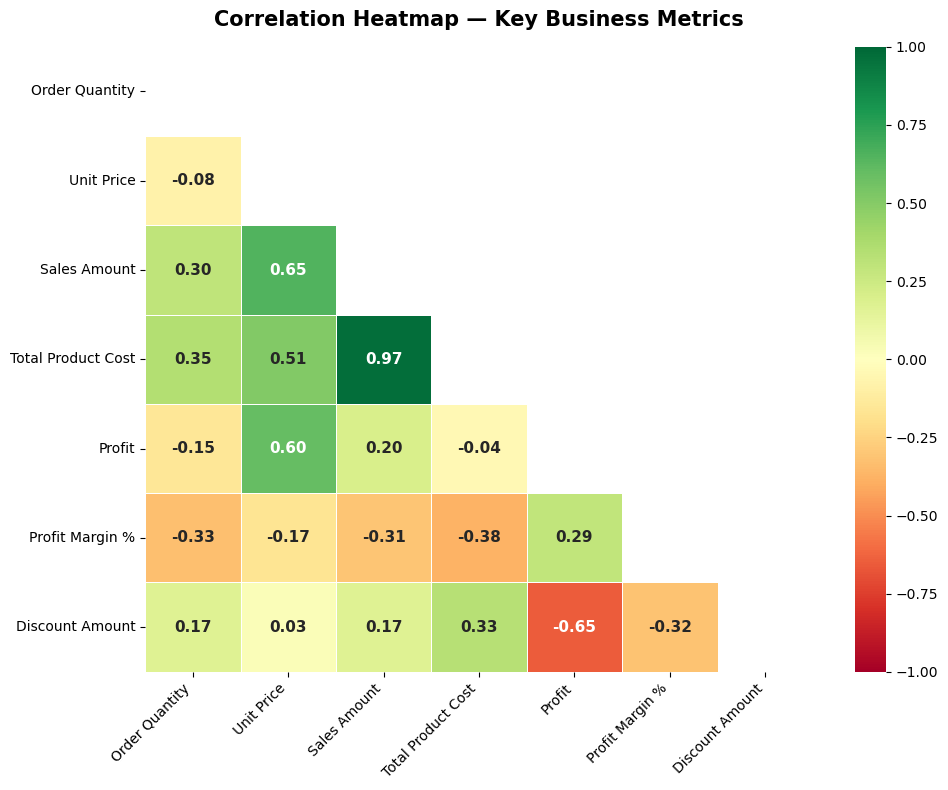

Chart saved


In [51]:
# =============================================================
# STEP 13 — Correlation Heatmap
# =============================================================

corr_cols = ['Order Quantity', 'Unit Price', 'Sales Amount', 
             'Total Product Cost', 'Profit', 
             'Profit Margin %', 'Discount Amount']

corr_matrix = master[corr_cols].corr().round(2)

plt.figure(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            mask=mask,
            linewidths=0.5,
            linecolor='white',
            vmin=-1, vmax=1,
            annot_kws={'size': 11, 'weight': 'bold'})

plt.title('Correlation Heatmap — Key Business Metrics', 
          fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('step13_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [52]:
# =============================================================
# STEP 14 — RFM Customer Segmentation
# =============================================================

# Use B2C customers only
b2c = master[master['CustomerType'] == 'B2C'].copy()

# Reference date = day after last transaction
reference_date = b2c['OrderDate'].max() + pd.Timedelta(days=1)

rfm = b2c.groupby('Customer').agg(
    Recency=('OrderDate', lambda x: (reference_date - x.max()).days),
    Frequency=('SalesOrderLineKey', 'count'),
    Monetary=('Sales Amount', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print("===== RFM TABLE (First 10) =====\n")
print(rfm.head(10).to_string())
print(f"\nRFM Shape: {rfm.shape}")
print(f"\nRecency  — Min: {rfm['Recency'].min()} days, Max: {rfm['Recency'].max()} days")
print(f"Frequency — Min: {rfm['Frequency'].min()}, Max: {rfm['Frequency'].max()}")
print(f"Monetary  — Min: ${rfm['Monetary'].min()}, Max: ${rfm['Monetary'].max()}")

===== RFM TABLE (First 10) =====

          Customer  Recency  Frequency  Monetary
0      Aaron Adams      261          4    117.96
1  Aaron Alexander       32          1     69.99
2      Aaron Allen      774          1   3399.99
3      Aaron Baker      127          2   1750.98
4     Aaron Bryant      172          5    133.96
5     Aaron Butler       19          2     14.98
6   Aaron Campbell      126          2   1155.48
7     Aaron Carter       23          2     39.98
8       Aaron Chen      185          2     39.98
9    Aaron Coleman       40          3     61.96

RFM Shape: (18400, 4)

Recency  — Min: 1 days, Max: 1081 days
Frequency — Min: 1, Max: 68
Monetary  — Min: $2.29, Max: $15999.1


In [53]:
# STEP 14 — Assign RFM Scores (1-5)

# Recency — LOWER days = BETTER = higher score
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, 
                          labels=[5, 4, 3, 2, 1])

# Frequency — HIGHER count = BETTER = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 
                          q=5, labels=[1, 2, 3, 4, 5])

# Monetary — HIGHER amount = BETTER = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, 
                          labels=[1, 2, 3, 4, 5])

# Combine into one RFM Score
rfm['RFM_Score'] = (rfm['R_Score'].astype(int) + 
                    rfm['F_Score'].astype(int) + 
                    rfm['M_Score'].astype(int))

print("===== RFM SCORES =====\n")
print(rfm[['Customer', 'Recency', 'Frequency', 'Monetary', 
           'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10).to_string())
print(f"\nRFM Score Range: {rfm['RFM_Score'].min()} to {rfm['RFM_Score'].max()}")

===== RFM SCORES =====

          Customer  Recency  Frequency  Monetary R_Score F_Score M_Score  RFM_Score
0      Aaron Adams      261          4    117.96       2       4       3          9
1  Aaron Alexander       32          1     69.99       5       1       2          8
2      Aaron Allen      774          1   3399.99       1       1       5          7
3      Aaron Baker      127          2   1750.98       3       1       4          8
4     Aaron Bryant      172          5    133.96       3       5       3         11
5     Aaron Butler       19          2     14.98       5       1       1          7
6   Aaron Campbell      126          2   1155.48       3       1       3          7
7     Aaron Carter       23          2     39.98       5       1       1          7
8       Aaron Chen      185          2     39.98       3       1       1          5
9    Aaron Coleman       40          3     61.96       5       3       2         10

RFM Score Range: 3 to 15


In [54]:
# =============================================================
# STEP 15 — Customer Segment Labeling
# =============================================================

def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    score = row['RFM_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and score >= 10:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and score >= 8:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4:
        return 'Cannot Lose Them'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('Customer', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1).reset_index()

segment_summary = segment_summary.sort_values('Customer_Count', ascending=False)

print("===== CUSTOMER SEGMENTS =====\n")
print(segment_summary.to_string())

===== CUSTOMER SEGMENTS =====

               Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary
4      Loyal Customers            4248         90.9            4.7        1798.9
5      Needs Attention            4151        231.1            2.0         460.3
0              At Risk            2807        268.6            4.2        2903.9
6        New Customers            2522         58.1            1.7         637.7
2            Champions            1775         63.2            5.5        4339.5
7  Potential Loyalists            1312        125.8            2.8         484.3
3                 Lost            1178        504.6            1.2        1428.7
1     Cannot Lose Them             407        266.2            3.6          62.7


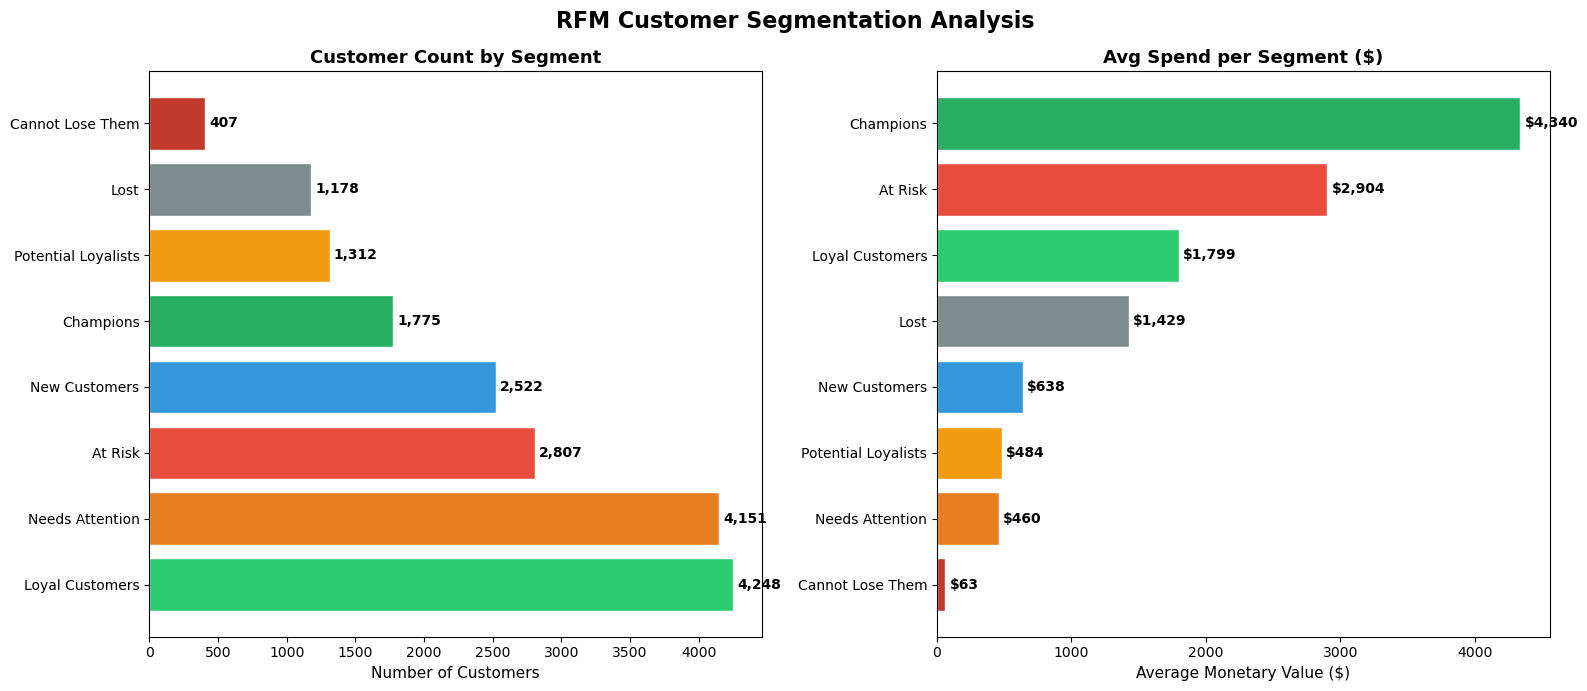

Chart saved


In [55]:
# STEP 15 — RFM Segment Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

colors_map = {
    'Champions': '#27ae60',
    'Loyal Customers': '#2ecc71',
    'Potential Loyalists': '#f39c12',
    'New Customers': '#3498db',
    'Needs Attention': '#e67e22',
    'At Risk': '#e74c3c',
    'Cannot Lose Them': '#c0392b',
    'Lost': '#7f8c8d'
}

colors = [colors_map[s] for s in segment_summary['Segment']]

# Chart 1 — Customer Count per Segment
bars1 = ax1.barh(segment_summary['Segment'],
                 segment_summary['Customer_Count'],
                 color=colors, edgecolor='white')
for bar, val in zip(bars1, segment_summary['Customer_Count']):
    ax1.text(bar.get_width() + 30,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontweight='bold', fontsize=10)
ax1.set_title('Customer Count by Segment', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Customers', fontsize=11)

# Chart 2 — Avg Monetary per Segment
segment_by_money = segment_summary.sort_values('Avg_Monetary', ascending=True)
colors2 = [colors_map[s] for s in segment_by_money['Segment']]
bars2 = ax2.barh(segment_by_money['Segment'],
                 segment_by_money['Avg_Monetary'],
                 color=colors2, edgecolor='white')
for bar, val in zip(bars2, segment_by_money['Avg_Monetary']):
    ax2.text(bar.get_width() + 30,
             bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontweight='bold', fontsize=10)
ax2.set_title('Avg Spend per Segment ($)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Average Monetary Value ($)', fontsize=11)

plt.suptitle('RFM Customer Segmentation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('step15_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")